<a href="https://colab.research.google.com/github/peakodev/data_science/blob/main/home_08/HW8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [74]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [75]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [76]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

In [77]:
# Створимо нейронну мережу

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        # from leonid explanation use initializer
        # initializer = K.initializers.GlorotNormal(seed=1)
        # self.w = tf.Variable(initializer(shape=(in_features, out_features)), name="w")
        # self.b = tf.Variable(initializer(shape=(1, out_features)), name="b")

        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)
        else:
            return tf.nn.sigmoid(y)

class NN(tf.Module):
  def __init__(self, name=None):
    super().__init__(name=name)

    # Перший шар, який складається з 128 нейронів
    self.layer1 = DenseLayer(num_features, n_hidden_1)

    # Другий шар, який складається з 256 нейронів
    self.layer2 = DenseLayer(n_hidden_1, n_hidden_2)

    # Вихідний шар
    self.out_layer = DenseLayer(n_hidden_2, num_classes)

  def __call__(self, x):
    # Передача даних через перші два шари та вихідний шар з функцією активації softmax
    x = self.layer1(x)
    x = self.layer2(x)

    x = self.out_layer(x, activation=1)

    return x

In [78]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    # Закодувати label в one hot vector
    y_true = tf.one_hot(y_true, depth=num_classes)

    # Значення передбачення, щоб уникнути помилки log(0).
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
    y_true = tf.cast(y_true, tf.int64)

    # Отримання передбачених класів (індекс максимального значення)
    y_pred_classes = tf.argmax(y_pred, axis=1)

    # Порівняння передбачених класів з реальними
    correct_prediction = tf.equal(y_pred_classes, y_true)

    # Обчислення середнього значення
    accuracy_value = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

    return accuracy_value

In [79]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")

# Функція навчання нейромережі
def train(neural_net, input_x, output_y):
    # Для налаштування вагів мережі будемо використовувати стохастичний градієнтний спуск
    optimizer = tf.optimizers.Adam(learning_rate)

    # Активація автоматичного диференціювання
    with tf.GradientTape() as g:
        pred = neural_net(input_x)
        loss = cross_entropy(pred, output_y)

        # Отримаємо список оптимізованих параметрів
        trainable_variables = neural_net.trainable_variables

        # Обчислимо за ними значення градієнта
        gradients = g.gradient(loss, trainable_variables)

        # Модифікуємо параметри
        optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss

In [80]:
# Тренування мережі

loss_history = []  # кожні display_step кроків зберігай в цьому списку поточну помилку нейромережі
accuracy_history = [] # кожні display_step кроків зберігай в цьому списку поточну точність нейромережі

# У цьому циклі ми будемо проводити навчання нейронної мережі
# із тренувального датасета train_data вилучи випадкову підмножину, на якій
# відбудеться тренування. Використовуй метод take, доступний для тренувального датасета.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Оновлюємо ваги нейронної мережі
    loss = train(neural_net, batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)

        # Обчислення поточної точності
        acc = accuracy(pred, batch_y)

        loss_history.append(loss.numpy())
        accuracy_history.append(acc.numpy())

        print(f"step: {step}, loss: {loss.numpy()}, accuracy: {acc.numpy()}")


step: 100, loss: 423.81988525390625, accuracy: 0.6484375
step: 200, loss: 273.1558837890625, accuracy: 0.7734375
step: 300, loss: 218.03338623046875, accuracy: 0.8125
step: 400, loss: 173.78439331054688, accuracy: 0.828125
step: 500, loss: 92.42347717285156, accuracy: 0.90625
step: 600, loss: 151.44630432128906, accuracy: 0.85546875
step: 700, loss: 107.03937530517578, accuracy: 0.89453125
step: 800, loss: 103.24978637695312, accuracy: 0.91015625
step: 900, loss: 99.62307739257812, accuracy: 0.91015625
step: 1000, loss: 84.70106506347656, accuracy: 0.93359375
step: 1100, loss: 54.11199951171875, accuracy: 0.9375
step: 1200, loss: 86.95504760742188, accuracy: 0.92578125
step: 1300, loss: 114.60234069824219, accuracy: 0.8984375
step: 1400, loss: 53.750152587890625, accuracy: 0.953125
step: 1500, loss: 75.04011535644531, accuracy: 0.95703125
step: 1600, loss: 65.68106079101562, accuracy: 0.9453125
step: 1700, loss: 40.86324691772461, accuracy: 0.9609375
step: 1800, loss: 59.73759078979492

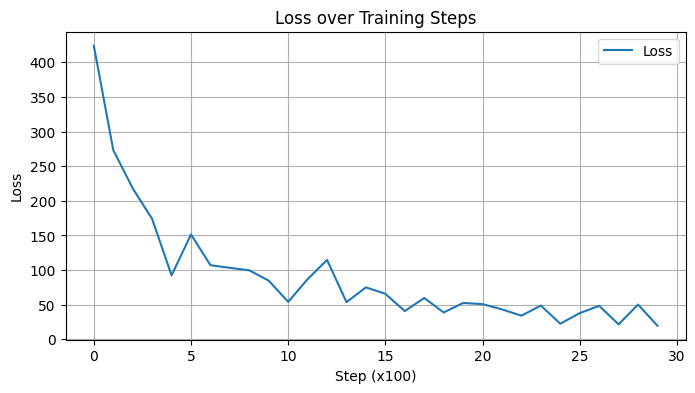

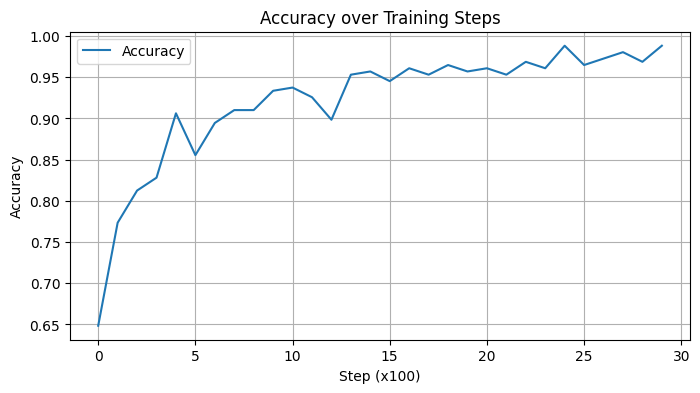

In [81]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt

# Виведіть графік функції втрат
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='Loss')
# plt.plot(range(1, len(loss_history) + 1), loss_history, label='Loss')
plt.xlabel('Step (x100)')
plt.ylabel('Loss')
plt.title('Loss over Training Steps')
plt.legend()
plt.grid(True)
plt.show()

# Виведіть графік точності
plt.figure(figsize=(8, 4))
plt.plot(accuracy_history, label='Accuracy')
# plt.plot(range(1, len(accuracy_history) + 1), accuracy_history, label='Accuracy')
plt.xlabel('Step (x100)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Training Steps')
plt.legend()
plt.grid(True)
plt.show()


In [82]:
# Обчисліть точність навченої нейромережі
train_predictions = neural_net(x_train)
train_acc = accuracy(train_predictions, y_train)
print(f"Точність навченої нейромережі: {train_acc.numpy()}")

# Тестування моделі на тестових даних

Точність навченої нейромережі: 0.9643999934196472


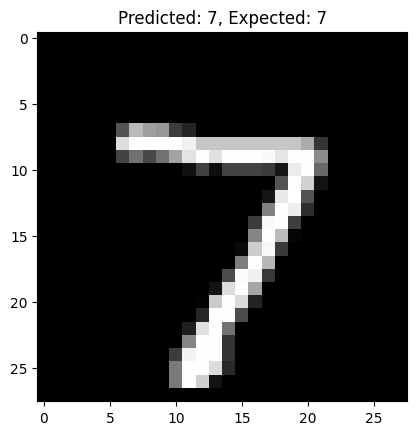

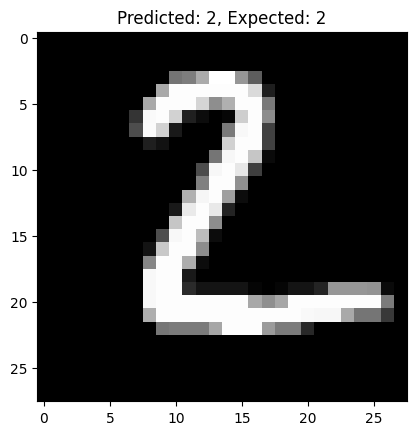

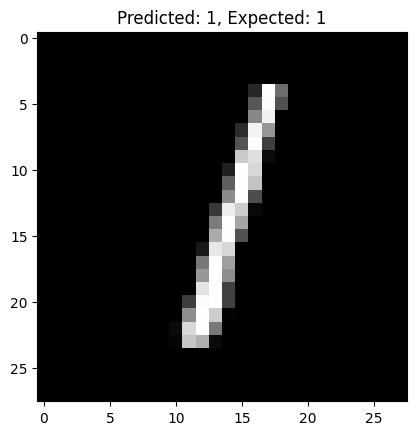

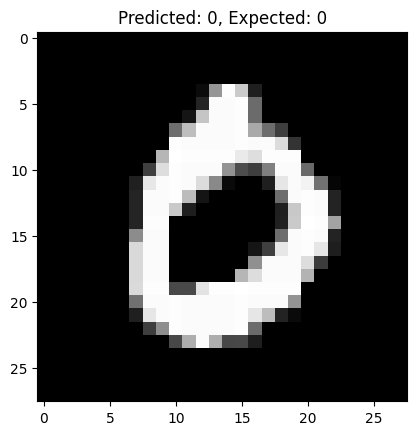

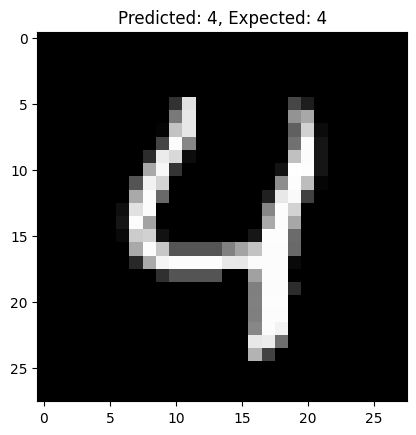

In [83]:
# Протестуйте навчену нейромережу на 10 зображеннях. З тестової вибірки візьміть 5
# випадкових зображень і передайте їх у нейронну мережу.
# Виведіть зображення та випишіть  поруч відповідь нейромережі.
# Зробіть висновок про те, чи помиляється твоя нейронна мережа, і якщо так, то як часто?

test_images = x_test[:5]
test_labels = y_test[:5]

predictions = neural_net(test_images)

for test_image, prediction, expected in zip(test_images, predictions.numpy().argmax(axis=1), test_labels):
    plt.imshow(test_image.reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {prediction}, Expected: {expected}")
    plt.show()


